In [2]:

%load_ext autoreload
%autoreload 2

import sys
from scipy.stats import sem

file_path = '/Users/michaelfinch/CA1-interneuron-GLM' #Mac
#file_path=r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM"

sys.path.append(file_path)

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *

from finding_weights_over_NDNF_utils import *

# activity_dict, predicted_activity_dict_NDNF_new, filtered_factors_dict, new_NDNF_activity_dict, new_NDNF_velocity_dict, residual_activity_dict_NDNF_new = load_data_regular(file_path=file_path, name="NDNFanalC", new_NDNF=True)
# GLM_params, activity_dict, double_predicted_activity_dict_NDNF_new, factors_dict, filtered_factors_dict, residual_activity_dict_NDNF_new = load_data_regular(file_path=file_path, name="NDNFanalC", new_NDNF=True)
# GLM_params_old_NDNF, activity_dict_old_NDNF, double_predicted_activity_dict_NDNF_old, factors_dict_old_NDNF, filtered_factors_dict_old_NDNF, residual_activity_dict_NDNF_old = load_data_regular(file_path=file_path, name="NDNFindivsomata_GLM", new_NDNF=False)
GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path=file_path, name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path=file_path, name="EC_GLM", new_NDNF=False)
GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path=file_path, name="NDNF_E1A1B", new_NDNF=True)

fixed_factors_dict_NDNF_newest = subset_factors(factors_dict_NDNF_newest)
fixed_residual_activity_dict_NDNF_newest = subset_factors(residual_activity_dict_NDNF_newest)
fixed_activity_dict_NDNF_newest = subset_factors(activity_dict_NDNF_newest)



/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
def get_probabilites_dict_full(cell_SST_model_ranks20_kmeans_reassign_x00):
    probabilites_per_animal_dict = {}

    for animal in cell_SST_model_ranks20_kmeans_reassign_x00[20]:
        cell_dict = {}
        for cell in cell_SST_model_ranks20_kmeans_reassign_x00[20][animal]:
            labels = cell_SST_model_ranks20_kmeans_reassign_x00[20][animal][cell][1][f"cell_{cell}"]["labels_dict"]["clusters_chosen_3"]
            
            cell_dict[cell] = {} 

            label_probs = sliding_window_probabilities(labels, window_size=10)

            probs_0 = label_probs.get(0, np.zeros(len(labels)))  
            probs_1 = label_probs.get(1, np.zeros(len(labels)))
            probs_2 = label_probs.get(2, np.zeros(len(labels)))

            
            dominance_list = []
            for i in range(len(probs_0)):
                trial_0 = probs_0[i]
                trial_1 = probs_1[i]
                trial_2 = probs_2[i]
                
                trial_0_sq = trial_0**2
                trial_1_sq = trial_1**2
                trial_2_sq = trial_2**2
                
                numerator = (trial_0_sq + trial_1_sq + trial_2_sq)
                denominator = (trial_0 + trial_1 + trial_2)
                
                if denominator == 0:
                    dominance = np.nan  # Protect against division by zero
                else:
                    dominance = numerator / (denominator**2)  # corrected formula!

                dominance_list.append(dominance)
            
            dominance_array = np.array(dominance_list)
            
            cell_dict[cell]["probs_0"] = probs_0
            cell_dict[cell]["probs_1"] = probs_1
            cell_dict[cell]["probs_2"] = probs_2
            cell_dict[cell]["dominance_array"] = dominance_array
            
        probabilites_per_animal_dict[animal] = cell_dict
    
    return probabilites_per_animal_dict

def sliding_window_probabilities(labels, window_size=10):
    labels = np.array(labels)
    unique_labels = np.unique(labels)
    n = len(labels)

    # Dictionary to hold probability lists per label
    label_probs = {label: [] for label in unique_labels}

    for start in range(n - window_size + 1):
        window = labels[start:start + window_size]
        counts = np.bincount(window, minlength=unique_labels.max() + 1)
        probs = counts / window_size

        for label in unique_labels:
            label_probs[label].append(probs[label])

    # Convert lists to arrays
    for label in label_probs:
        label_probs[label] = np.array(label_probs[label])

    return label_probs

In [4]:
################ clusters must be of size 3+

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_SST_model_ranks20_contig_x00_cells"
cell_SST_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_EC_model_ranks20_contig_x00_cells"
cell_EC_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_contig_x00_cell"
cell_NDNF_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)




Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

In [5]:


mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell"
testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell"
testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)


mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell"
real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell = get_model_data_per_cell(mse_dir)

fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue = {20: {}}
for idx, animal in enumerate(real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell[20]):
    if 17<idx<31:
        fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue[20][animal-18] = real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell[20][animal]

        


Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

In [6]:

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_SST_model_ranks20_contig_x00_cells"
cell_SST_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_EC_model_ranks20_contig_x00_cells"
cell_EC_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_contig_x00_cell"
cell_NDNF_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

def get_cp_dict(cell_SST_model_ranks20_contig_x00):
    changepoints_dict = {}
    for animal in cell_SST_model_ranks20_contig_x00[20]:
        changepoints_cell_dict = {}
        for cell in cell_SST_model_ranks20_contig_x00[20][animal]:
            labels = cell_SST_model_ranks20_contig_x00[20][animal][cell][1][f'cell_{cell}']["labels_dict"]["clusters_chosen_3"]
            changepoints = np.where(np.diff(labels) != 0)[0]
            changepoints_cell_dict[cell] = changepoints
        changepoints_dict[animal] = changepoints_cell_dict

    return changepoints_dict



fixed_model_dict_NDNF_newest = get_fixed_model_dict_NDNF_newest(cell_NDNF_model_ranks20_contig_x00)

cp_dict_EC = get_cp_dict(cell_EC_model_ranks20_contig_x00)
cp_dict_NDNF = get_cp_dict(fixed_model_dict_NDNF_newest)
cp_dict_SST = get_cp_dict(cell_SST_model_ranks20_contig_x00)

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

In [ ]:
    
def get_labels_activities(testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, sort_by_peak=True):
    before_field_list_activity = []
    near_field_list_activity = []
    after_field_list_activity = []

    before_field_list_probs = []
    near_field_list_probs = []
    after_field_list_probs = []


    probability_activity_dict = {}

    for animal in testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell[20]:

        probability_activity_dict_cell = {}

        for cell in testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell[20][animal]:


            p = len(testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][1][f"cell_{cell}"]["cluster_trial_mean_dict"]["clusters_chosen_3"])
            if p ==3:

                probs_0_activity = testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][1][f"cell_{cell}"]["cluster_trial_mean_dict"]["clusters_chosen_3"][0]
                probs_1_activity = testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][1][f"cell_{cell}"]["cluster_trial_mean_dict"]["clusters_chosen_3"][1]
                probs_2_activity = testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][1][f"cell_{cell}"]["cluster_trial_mean_dict"]["clusters_chosen_3"][2]

                labels = testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][1][f"cell_{cell}"]["labels_dict"]["clusters_chosen_3"]

                label_probs = sliding_window_probabilities(labels, window_size=10)

                probs_0 = label_probs.get(0, np.zeros(49))  # fallback if missing
                probs_1 = label_probs.get(1, np.zeros(49))
                probs_2 = label_probs.get(2, np.zeros(49))

                if sort_by_peak:
                    max_0 = np.argmax(probs_0_activity)
                else:
                    max_0 = np.argmin(probs_0_activity)

                if max_0 <=15:
                    probability_activity_dict[cell] = {"before":probs_0}
                    before_field_list_activity.append(probs_0_activity[:49])
                    before_field_list_probs.append(probs_0[:49])
                elif  15 < max_0 <35:
                    near_field_list_activity.append(probs_0_activity[:49])
                    near_field_list_probs.append(probs_0[:49])
                elif  max_0<=35:
                    after_field_list_activity.append(probs_0_activity[:49])
                    after_field_list_probs.append(probs_0[:49])

                if sort_by_peak:
                    max_1 = np.argmax(probs_1_activity)
                else:
                    max_1 = np.argmin(probs_1_activity)

                max_1 = np.argmax(probs_1_activity)
                if max_1 <=15:
                    before_field_list_activity.append(probs_1_activity[:49])
                    before_field_list_probs.append(probs_1[:49])
                elif  15 < max_1 <35:
                    near_field_list_activity.append(probs_1_activity[:49])
                    near_field_list_probs.append(probs_1[:49])
                elif  max_1<=35:
                    after_field_list_activity.append(probs_1_activity[:49])
                    after_field_list_probs.append(probs_1[:49])

                if sort_by_peak:
                    max_2 = np.argmax(probs_2_activity)
                else:
                    max_2 = np.argmin(probs_2_activity)

                max_2 = np.argmax(probs_2_activity)
                if max_2 <=15:
                    before_field_list_activity.append(probs_2_activity[:49])
                    before_field_list_probs.append(probs_2[:49])
                elif  15 < max_2 <35:
                    near_field_list_activity.append(probs_2_activity[:49])
                    near_field_list_probs.append(probs_2[:49])
                elif  max_2<=35:
                    after_field_list_activity.append(probs_2_activity[:49])
                    after_field_list_probs.append(probs_2[:49])



                probability_activity_dict_cell[cell] = {}

    return before_field_list_activity, near_field_list_activity, after_field_list_activity, before_field_list_probs, near_field_list_probs, after_field_list_probs 


before_field_list_activity_SST, near_field_list_activity_SST, after_field_list_activity_SST, before_field_list_probs_SST, near_field_list_probs_SST, after_field_list_probs_SST = get_labels_activities(testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, sort_by_peak=True)
before_field_list_activity_EC, near_field_list_activity_EC, after_field_list_activity_EC, before_field_list_probs_EC, near_field_list_probs_EC, after_field_list_probs_EC = get_labels_activities(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, sort_by_peak=True)
before_field_list_activity_NDNF, near_field_list_activity_NDNF, after_field_list_activity_NDNF, before_field_list_probs_NDNF, near_field_list_probs_NDNF, after_field_list_probs_NDNF = get_labels_activities(fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, sort_by_peak=True)


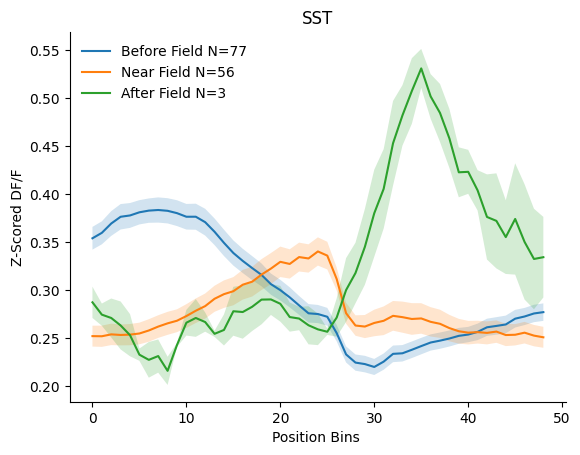

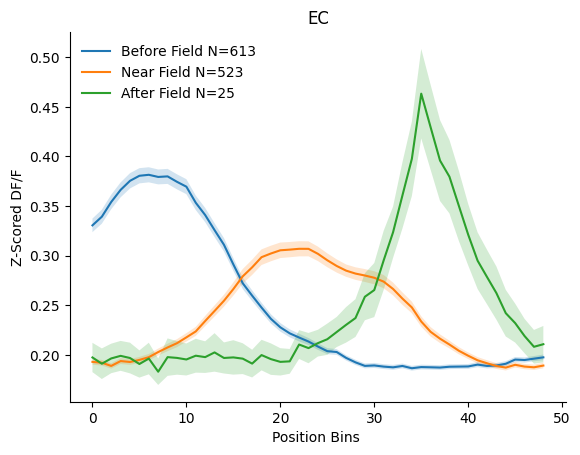

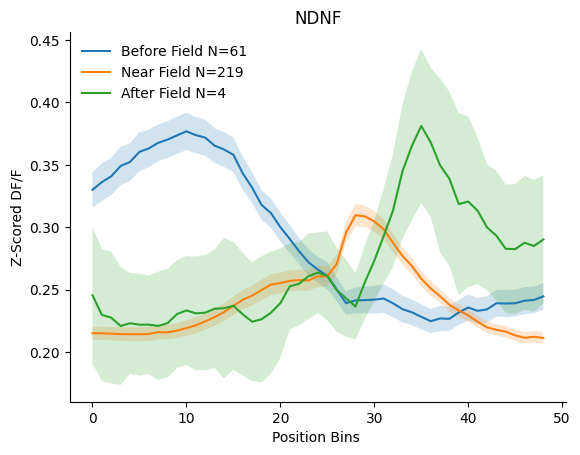

In [87]:

def plot_activity_clusters(before_field_list_activity, near_field_list_activity, after_field_list_activity, title="SST"):
    
    before_field_list_activity_array = np.array(before_field_list_activity)

    mean_before_field_list_activity_array = np.mean(before_field_list_activity_array, axis=0)
    sem_before_field_list_activity_array = sem(before_field_list_activity_array, axis=0)

    plt.plot(mean_before_field_list_activity_array, label=f'Before Field N={before_field_list_activity_array.shape[0]}')
    plt.fill_between(range(len(sem_before_field_list_activity_array)), mean_before_field_list_activity_array+sem_before_field_list_activity_array, mean_before_field_list_activity_array-sem_before_field_list_activity_array, alpha=0.2)


    near_field_list_activity_array = np.array(near_field_list_activity)

    mean_near_field_list_activity_array = np.mean(near_field_list_activity_array, axis=0)
    sem_near_field_list_activity_array = sem(near_field_list_activity_array, axis=0)

    plt.plot(mean_near_field_list_activity_array, label=f'Near Field N={near_field_list_activity_array.shape[0]}')
    plt.fill_between(range(len(sem_near_field_list_activity_array)), mean_near_field_list_activity_array+sem_near_field_list_activity_array, mean_near_field_list_activity_array-sem_near_field_list_activity_array, alpha=0.2)

    after_field_list_activity_array = np.array(after_field_list_activity)

    mean_after_field_list_activity_array = np.mean(after_field_list_activity_array, axis=0)
    sem_after_field_list_activity_array = sem(after_field_list_activity_array, axis=0)

    plt.plot(mean_after_field_list_activity_array, label=f'After Field N={after_field_list_activity_array.shape[0]}')
    plt.fill_between(range(len(sem_after_field_list_activity_array)), mean_after_field_list_activity_array+sem_after_field_list_activity_array, mean_after_field_list_activity_array-sem_after_field_list_activity_array, alpha=0.2)

    plt.legend()
    plt.title(title)
    plt.ylabel("Z-Scored DF/F")
    plt.xlabel("Position Bins ")
    plt.show()

plot_activity_clusters(before_field_list_activity_SST, near_field_list_activity_SST, after_field_list_activity_SST, title="SST")
plot_activity_clusters(before_field_list_activity_EC, near_field_list_activity_EC, after_field_list_activity_EC, title="EC")
plot_activity_clusters(before_field_list_activity_NDNF, near_field_list_activity_NDNF, after_field_list_activity_NDNF, title="NDNF")

(77, 49)


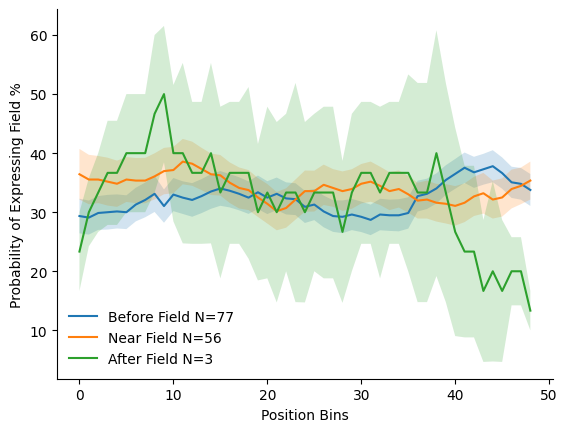

(613, 49)


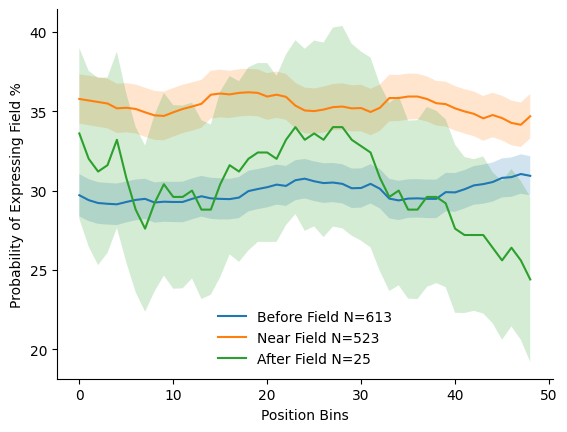

(61, 49)


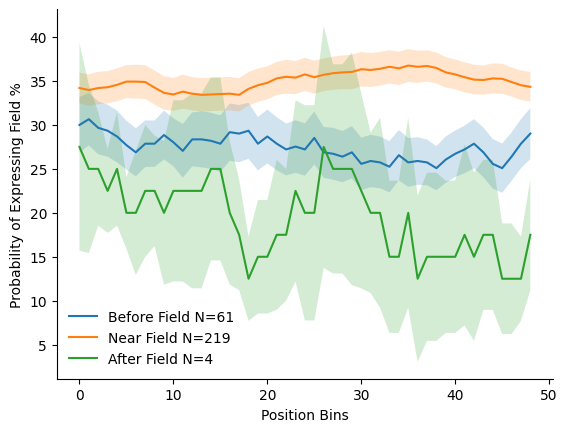

In [88]:

def plot_probabilities(before_field_list_probs, near_field_list_probs, after_field_list_probs):


    before_field_list_probs_array = np.array(before_field_list_probs)

    print(before_field_list_probs_array.shape)

    mean_before_field_list_probs_array = np.mean(before_field_list_probs_array, axis=0) *100
    sem_before_field_list_probs_array = sem(before_field_list_probs_array, axis=0)*100

    plt.plot(mean_before_field_list_probs_array, label=f'Before Field N={before_field_list_probs_array.shape[0]}')
    plt.fill_between(range(len(sem_before_field_list_probs_array)), mean_before_field_list_probs_array+sem_before_field_list_probs_array, mean_before_field_list_probs_array-sem_before_field_list_probs_array, alpha=0.2)


    near_field_list_probs_array = np.array(near_field_list_probs)

    mean_near_field_list_probs_array = np.mean(near_field_list_probs_array, axis=0)*100
    sem_near_field_list_probs_array = sem(near_field_list_probs_array, axis=0)*100

    plt.plot(mean_near_field_list_probs_array, label=f'Near Field N={near_field_list_probs_array.shape[0]}')
    plt.fill_between(range(len(sem_near_field_list_probs_array)), mean_near_field_list_probs_array+sem_near_field_list_probs_array, mean_near_field_list_probs_array-sem_near_field_list_probs_array, alpha=0.2)

    after_field_list_probs_array = np.array(after_field_list_probs)

    mean_after_field_list_probs_array = np.mean(after_field_list_probs_array, axis=0)*100
    sem_after_field_list_probs_array = sem(after_field_list_probs_array, axis=0)*100

    plt.plot(mean_after_field_list_probs_array, label=f'After Field N={after_field_list_probs_array.shape[0]}')
    plt.fill_between(range(len(sem_after_field_list_probs_array)), mean_after_field_list_probs_array+sem_after_field_list_probs_array, mean_after_field_list_probs_array-sem_after_field_list_probs_array, alpha=0.2)

    plt.legend()
    plt.ylabel("Probability of Expressing Field %")
    plt.xlabel("Position Bins")
    plt.show()


plot_probabilities(before_field_list_probs_SST, near_field_list_probs_SST, after_field_list_probs_SST)
plot_probabilities(before_field_list_probs_EC, near_field_list_probs_EC, after_field_list_probs_EC)
plot_probabilities(before_field_list_probs_NDNF, near_field_list_probs_NDNF, after_field_list_probs_NDNF)


In [81]:
for i in before_field_list_probs_EC:
    if len(i) <54:
        print("oops")
        print(len(i))

oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49
oops
49


In [9]:
    
def get_labels_activities_eml(testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, cp_dict_SST, sort_by_peak=True):

    probability_activity_dict = {}

    for animal in testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell[20]:

        probability_activity_dict_cell = {}

        for cell in testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell[20][animal]:

            cp_early = cp_dict_SST[animal][cell][0]
            cp_late = cp_dict_SST[animal][cell][1]

            p = len(testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][1][f"cell_{cell}"]["cluster_trial_mean_dict"]["clusters_chosen_3"])
            if p ==3:

                probs_0_activity = testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][1][f"cell_{cell}"]["cluster_trial_mean_dict"]["clusters_chosen_3"][0]
                probs_1_activity = testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][1][f"cell_{cell}"]["cluster_trial_mean_dict"]["clusters_chosen_3"][1]
                probs_2_activity = testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][1][f"cell_{cell}"]["cluster_trial_mean_dict"]["clusters_chosen_3"][2]

                labels = testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][1][f"cell_{cell}"]["labels_dict"]["clusters_chosen_3"]

                label_probs = sliding_window_probabilities(labels, window_size=10)

                probs_0 = label_probs.get(0, len(labels))  # fallback if missing
                probs_1 = label_probs.get(1, len(labels))
                probs_2 = label_probs.get(2, len(labels))

                if sort_by_peak:
                    max_0 = np.argmax(probs_0_activity)
                else:
                    max_0 = np.argmin(probs_0_activity)


                probs_0_early = probs_0[:cp_early]
                probs_0_middle = probs_0[cp_early:cp_late]
                probs_0_late = probs_0[:cp_late]

                if max_0 <=15:

                    probability_activity_dict_cell[cell] = {"before_early":probs_0_early,
                                                       "before_middle":probs_0_middle,
                                                       "before_late":probs_0_late}
                    
                elif  15 < max_0 <35:

                    probability_activity_dict_cell[cell] = {"near_early":probs_0_early,
                                                       "near_middle":probs_0_middle,
                                                       "near_late":probs_0_late}
                
                elif  max_0<=35:
                    probability_activity_dict_cell[cell] = {"after_early":probs_0_early,
                                                       "after_middle":probs_0_middle,
                                                       "after_late":probs_0_late}

                if sort_by_peak:
                    max_1 = np.argmax(probs_1_activity)
                else:
                    max_1 = np.argmin(probs_1_activity)


                probs_1_early = probs_1[:cp_early]
                probs_1_middle = probs_1[cp_early:cp_late]
                probs_1_late = probs_1[:cp_late]


                if max_1 <=15:
                    probability_activity_dict_cell[cell] = {"before_early":probs_1_early,
                                                       "before_middle":probs_1_middle,
                                                       "before_late":probs_1_late}
                
                elif  15 < max_1 <35:

                    probability_activity_dict_cell[cell] = {"near_early":probs_1_early,
                                                       "near_middle":probs_1_middle,
                                                       "near_late":probs_1_late}
                
                elif  max_1<=35:

                    probability_activity_dict_cell[cell] = {"after_early":probs_1_early,
                                                       "after_middle":probs_1_middle,
                                                       "after_late":probs_1_late}

                if sort_by_peak:
                    max_2 = np.argmax(probs_2_activity)
                else:
                    max_2 = np.argmin(probs_2_activity)

                probs_2_early = probs_2[:cp_early]
                probs_2_middle = probs_2[cp_early:cp_late]
                probs_2_late = probs_2[:cp_late]


                if max_2 <=15:
                    probability_activity_dict_cell[cell] = {"before_early":probs_2_early,
                                                       "before_middle":probs_2_middle,
                                                       "before_late":probs_2_late}
                elif  15 < max_2 <35:
                    probability_activity_dict_cell[cell] = {"near_early":probs_2_early,
                                                       "near_middle":probs_2_middle,
                                                       "near_late":probs_2_late}
                elif  max_2<=35:
                    probability_activity_dict_cell[cell] = {"after_early":probs_2_early,
                                                       "after_middle":probs_2_middle,
                                                       "after_late":probs_2_late}
                    
        probability_activity_dict[animal] = probability_activity_dict_cell



    return probability_activity_dict


probability_activity_dict_SST = get_labels_activities_eml(testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, cp_dict_SST, sort_by_peak=True)

# before_field_list_activity_EC, near_field_list_activity_EC, after_field_list_activity_EC, before_field_list_probs_EC, near_field_list_probs_EC, after_field_list_probs_EC = get_labels_activities2(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, sort_by_peak=True)
# before_field_list_activity_NDNF, near_field_list_activity_NDNF, after_field_list_activity_NDNF, before_field_list_probs_NDNF, near_field_list_probs_NDNF, after_field_list_probs_NDNF = get_labels_activities2(fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, sort_by_peak=True)


In [ ]:
for animal in probability_activity_dict_SST:
    for cell in probability_activity_dict_SST[animal]:
        .keys())

dict_keys(['before_early', 'before_middle', 'before_late'])
dict_keys(['near_early', 'near_middle', 'near_late'])
dict_keys(['near_early', 'near_middle', 'near_late'])
dict_keys(['near_early', 'near_middle', 'near_late'])
dict_keys(['near_early', 'near_middle', 'near_late'])
dict_keys(['before_early', 'before_middle', 'before_late'])
dict_keys(['near_early', 'near_middle', 'near_late'])
dict_keys(['before_early', 'before_middle', 'before_late'])
dict_keys(['before_early', 'before_middle', 'before_late'])
dict_keys(['near_early', 'near_middle', 'near_late'])
dict_keys(['before_early', 'before_middle', 'before_late'])
dict_keys(['before_early', 'before_middle', 'before_late'])
dict_keys(['before_early', 'before_middle', 'before_late'])
dict_keys(['before_early', 'before_middle', 'before_late'])
dict_keys(['before_early', 'before_middle', 'before_late'])
dict_keys(['before_early', 'before_middle', 'before_late'])
dict_keys(['near_early', 'near_middle', 'near_late'])
dict_keys(['before_ear

In [ ]:
######################## do not just use clusters chosen 3 --- you need to use the elbow 

In [186]:
    
def get_labels_activities_eml(testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, cp_dict_SST, sort_by_peak=True):

    probability_activity_dict = {}

    for idx, animal in enumerate(residual_activity_dict_SST):

        probability_activity_dict_cell = {}

        for idt, cell in enumerate(residual_activity_dict_SST[animal]):

            cp_early = cp_dict_SST[idx][idt][0]
            cp_late = cp_dict_SST[idx][idt][1]

            p = len(testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell[20][idx][idt][1][f"cell_{idt}"]["cluster_trial_mean_dict"]["clusters_chosen_3"])
            if p ==3:

                # probs_0_activity = testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][1][f"cell_{cell}"]["cluster_trial_mean_dict"]["clusters_chosen_3"][0]
                # probs_1_activity = testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][1][f"cell_{cell}"]["cluster_trial_mean_dict"]["clusters_chosen_3"][1]
                # probs_2_activity = testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][1][f"cell_{cell}"]["cluster_trial_mean_dict"]["clusters_chosen_3"][2]

                labels = testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell[20][idx][idt][1][f"cell_{idt}"]["labels_dict"]["clusters_chosen_3"]

                zero_trials = np.where(labels==0)[0]
                one_trials = np.where(labels==1)[0]
                two_trials = np.where(labels==2)[0]

                probs_0_activity = np.mean(residual_activity_dict_SST[animal][cell][:, zero_trials], axis=1)
                probs_1_activity = np.mean(residual_activity_dict_SST[animal][cell][:, one_trials], axis=1)
                probs_2_activity = np.mean(residual_activity_dict_SST[animal][cell][:, two_trials], axis=1)

                label_probs = sliding_window_probabilities(labels, window_size=10)

                probs_0 = label_probs.get(0, len(labels))  # fallback if missing
                probs_1 = label_probs.get(1, len(labels))
                probs_2 = label_probs.get(2, len(labels))


                before_dict = {}
                near_dict = {}
                after_dict = {}

                if sort_by_peak:
                    max_0 = np.argmax(probs_0_activity)
                else:
                    max_0 = np.argmin(probs_0_activity)


                probs_0_early = probs_0[:cp_early]
                probs_0_middle = probs_0[cp_early:cp_late]
                probs_0_late = probs_0[:cp_late]

                if max_0 <=15:

                    before_dict["before_early_0"] = probs_0_early
                    before_dict["before_middle_0"] = probs_0_middle
                    before_dict["before_late_0"] = probs_0_late
                    before_dict["activity_0"] = probs_0_activity

                    
                elif  15 < max_0 <35:

                    near_dict["near_early_0"] = probs_0_early
                    near_dict["near_middle_0"] = probs_0_middle
                    near_dict["near_late_0"] = probs_0_late
                    near_dict["activity_0"] = probs_0_activity
                
                else:
                    after_dict["after_early_0"] = probs_0_early
                    after_dict["after_middle_0"] = probs_0_middle
                    after_dict["after_late_0"] = probs_0_late
                    after_dict["activity_0"] = probs_0_activity

                if sort_by_peak:
                    max_1 = np.argmax(probs_1_activity)
                else:
                    max_1 = np.argmin(probs_1_activity)


                probs_1_early = probs_1[:cp_early]
                probs_1_middle = probs_1[cp_early:cp_late]
                probs_1_late = probs_1[:cp_late]


                if max_1 <=15:
                    before_dict["before_early_1"] = probs_1_early
                    before_dict["before_middle_1"] = probs_1_middle
                    before_dict["before_late_1"] = probs_1_late
                    before_dict["activity_1"] = probs_1_activity
                
                elif  15 < max_1 <35:

                    near_dict["near_early_1"] = probs_1_early
                    near_dict["near_middle_1"] = probs_1_middle
                    near_dict["near_late_1"] = probs_1_late
                    near_dict["activity_1"] = probs_1_activity
                
                else:

                    after_dict["after_early_1"] = probs_1_early
                    after_dict["after_middle_1"] = probs_1_middle
                    after_dict["after_late_1"] = probs_1_late
                    after_dict["activity_1"] = probs_1_activity

                if sort_by_peak:
                    max_2 = np.argmax(probs_2_activity)
                else:
                    max_2 = np.argmin(probs_2_activity)

                probs_2_early = probs_2[:cp_early]
                probs_2_middle = probs_2[cp_early:cp_late]
                probs_2_late = probs_2[:cp_late]


                if max_2 <=15:

                    before_dict["before_early_2"] = probs_2_early
                    before_dict["before_middle_2"] = probs_2_middle
                    before_dict["before_late_2"] = probs_2_late
                    before_dict["activity_2"] = probs_2_activity

                elif  15 < max_2 <35:
                    near_dict["near_early_2"] = probs_2_early
                    near_dict["near_middle_2"] = probs_2_middle
                    near_dict["near_late_2"] = probs_2_late
                    near_dict["activity_2"] = probs_2_activity
                else:
                    after_dict["after_early_2"] = probs_2_early
                    after_dict["after_middle_2"] = probs_2_middle
                    after_dict["after_late_2"] = probs_2_late
                    after_dict["activity_2"] = probs_2_activity
            
            probability_activity_dict_cell[idt] = {"before_dict":before_dict,
                                                    "near_dict":near_dict,
                                                    "after_dict":after_dict,
                                                    }
        probability_activity_dict[idx] = probability_activity_dict_cell



    return probability_activity_dict


################### SST wants to be sorted by trough 


probability_activity_dict_SST = get_labels_activities_eml(testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, cp_dict_SST, sort_by_peak=True)
probability_activity_dict_NDNF = get_labels_activities_eml(fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF, sort_by_peak=True)
probability_activity_dict_EC = get_labels_activities_eml(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, cp_dict_EC, sort_by_peak=True)

# before_field_list_activity_EC, near_field_list_activity_EC, after_field_list_activity_EC, before_field_list_probs_EC, near_field_list_probs_EC, after_field_list_probs_EC = get_labels_activities2(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, sort_by_peak=True)
# before_field_list_activity_NDNF, near_field_list_activity_NDNF, after_field_list_activity_NDNF, before_field_list_probs_NDNF, near_field_list_probs_NDNF, after_field_list_probs_NDNF = get_labels_activities2(fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, sort_by_peak=True)


In [ ]:
###### try sliding window =20

In [ ]:
###### we have a bunch of trials for each cell labelled in trial types by kmeans (len - num trials labelled as either a group 0, 1, 2, 3, etc)
###### we also have the mean activity of the cluster --- ex/ average all of the 0 or 1 or 2 cluster trials to get 50, average activity 
#since we have a timeseries of 0, 1, 2 etc trial typing take a sliding window average to get a probability of that trial typing expressing 
# label each trial type as a early, middle, late field by the argmax/min of its average activities peak location 




(50,)

In [78]:
def get_activity_early_gen(activity_dict_SST, cp_dict_SST):
    SST_dict_early = {}
    for idx, animal in enumerate(activity_dict_SST):
        SST_dict_early_cell = {}
        for idt, cell in enumerate(activity_dict_SST[animal]):
            cp_early = cp_dict_SST[idx][idt][0]
            SST_dict_early_cell[idt] = activity_dict_SST[animal][cell][:,:cp_early]
        SST_dict_early[idx] = SST_dict_early_cell

    return SST_dict_early

def get_activity_late_gen(activity_dict_SST, cp_dict_SST):
    SST_dict_late = {}
    for idx, animal in enumerate(activity_dict_SST):
        SST_dict_late_cell = {}
        for idt, cell in enumerate(activity_dict_SST[animal]):
            cp_late = cp_dict_SST[idx][idt][1]
            SST_dict_late_cell[idt] = activity_dict_SST[animal][cell][:,-cp_late:]
        SST_dict_late[idx] = SST_dict_late_cell

    return SST_dict_late


def get_activity_middle_gen(activity_dict_SST, cp_dict_SST):
    SST_dict_late = {}
    for idx, animal in enumerate(activity_dict_SST):
        SST_dict_late_cell = {}
        for idt, cell in enumerate(activity_dict_SST[animal]):
            cp_late = cp_dict_SST[idx][idt][1]
            cp_early = cp_dict_SST[idx][idt][0]
            SST_dict_late_cell[idt] = activity_dict_SST[animal][cell][:,cp_early:cp_late]
        SST_dict_late[idx] = SST_dict_late_cell

    return SST_dict_late

In [79]:
SST_data_dict_early_r = get_activity_early_gen(residual_activity_dict_SST, cp_dict_SST)
SST_data_dict_late_r = get_activity_late_gen(residual_activity_dict_SST, cp_dict_SST)
SST_data_dict_middle_r = get_activity_middle_gen(residual_activity_dict_SST, cp_dict_SST)

EC_data_dict_early_r = get_activity_early_gen(residual_activity_dict_EC, cp_dict_EC)
EC_data_dict_late_r = get_activity_late_gen(residual_activity_dict_EC, cp_dict_EC)
EC_data_dict_middle_r = get_activity_middle_gen(residual_activity_dict_EC, cp_dict_EC)

NDNF_data_dict_early_r = get_activity_early_gen(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF)
NDNF_data_dict_late_r = get_activity_late_gen(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF)
NDNF_data_dict_middle_r = get_activity_middle_gen(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF)

In [181]:
data_dict = probability_activity_dict_SST[0][0]
data_dict["near_dict"]

{'near_early_1': array([0.3, 0.2, 0.1, 0.1, 0.2, 0.2, 0.2, 0.3, 0.3, 0.3, 0.4, 0.4, 0.4,
        0.4]),
 'near_middle_1': array([0.4, 0.3, 0.3, 0.2, 0.3, 0.4, 0.3, 0.4, 0.4, 0.5, 0.4, 0.5, 0.6,
        0.7, 0.6, 0.5, 0.6, 0.5, 0.6, 0.5, 0.6, 0.5, 0.4, 0.3, 0.3, 0.4,
        0.4, 0.5, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.3, 0.3,
        0.4, 0.4, 0.4, 0.4, 0.5, 0.6, 0.6, 0.6, 0.7, 0.7, 0.7, 0.6, 0.7,
        0.7, 0.6, 0.6, 0.5, 0.4, 0.4, 0.4, 0.4, 0.4, 0.3, 0.3, 0.4, 0.3,
        0.3, 0.3, 0.3, 0.4, 0.3, 0.4, 0.5, 0.6, 0.5, 0.5, 0.5, 0.6, 0.6,
        0.6, 0.6, 0.5, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.3, 0.3, 0.4]),
 'near_late_1': array([0.3, 0.2, 0.1, 0.1, 0.2, 0.2, 0.2, 0.3, 0.3, 0.3, 0.4, 0.4, 0.4,
        0.4, 0.4, 0.3, 0.3, 0.2, 0.3, 0.4, 0.3, 0.4, 0.4, 0.5, 0.4, 0.5,
        0.6, 0.7, 0.6, 0.5, 0.6, 0.5, 0.6, 0.5, 0.6, 0.5, 0.4, 0.3, 0.3,
        0.4, 0.4, 0.5, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.3,
        0.3, 0.4, 0.4, 0.4, 0.4, 0.5, 0.6, 0.6, 0.6, 0.7, 0.7, 0

In [176]:
data_dict = probability_activity_dict_SST[0][0]
array = data_dict["near_dict"]["near_early_1"]
print(array)
print(f"mean_arrray {np.mean(array)}")



[0.3 0.2 0.1 0.1 0.2 0.2 0.2 0.3 0.3 0.3 0.4 0.4 0.4 0.4]
mean_arrray 0.2714285714285714


In [182]:
print([key for key in data_dict["near_dict"].keys() if "early" in key and "activity" not in key])


['near_early_1', 'near_early_2']


In [ ]:
eml=='early'
activity_dict = {}
prob_dict = {field_type: 0.0 for field_type in ["before", "near", "after"]}
for field_type in ["before", "near", "after"]:
    if f"{field_type}_dict" in data_dict:
        sub_dict = data_dict[f"{field_type}_dict"]

        # collect all relevant keys for this field_type and epoch
        prob_list = []
        for key in sub_dict:
            if eml in key and "activity" not in key:
                prob_list.append(np.nanmean(sub_dict[key]))  # be safe
            elif eml in key and "activity" in key:
                activity_dict[field_type] = sub_dict[key]

        if len(prob_list) > 0:
            prob_dict[field_type] = np.mean(prob_list)

prob_dict["near"]

In [200]:

def random_timeseries(initial_value: float, volatility: float, count: int):
    time_series = [initial_value, ]
    for _ in range(count):
        time_series.append(time_series[-1] + initial_value * random.gauss(0, 1) * volatility)
    return time_series

dict_keys(['before', 'after'])
field_probs before [0.37857143 0.35      ]
field_probs after [0.51960784 0.48039216]
dict_keys(['before', 'near', 'after'])
field_probs before [0.56666667 0.4        0.03333333]
field_probs after [0.56666667 0.4        0.03333333]
dict_keys(['near', 'after'])
field_probs before [0.37647059 0.44705882]
field_probs after [0.45714286 0.54285714]
dict_keys(['before', 'near', 'after'])
field_probs before [0.13333333 0.24444444 0.62222222]
field_probs after [0.13333333 0.24444444 0.62222222]
dict_keys(['before', 'near', 'after'])
field_probs before [0.23820225 0.53932584 0.22247191]
field_probs after [0.23820225 0.53932584 0.22247191]
dict_keys(['before', 'after'])
field_probs before [0.02352941 0.48823529]
field_probs after [0.04597701 0.95402299]
dict_keys(['before', 'near', 'after'])
field_probs before [0.5        0.14444444 0.35555556]
field_probs after [0.5        0.14444444 0.35555556]
dict_keys(['before', 'near', 'after'])
field_probs before [0.1296875 0

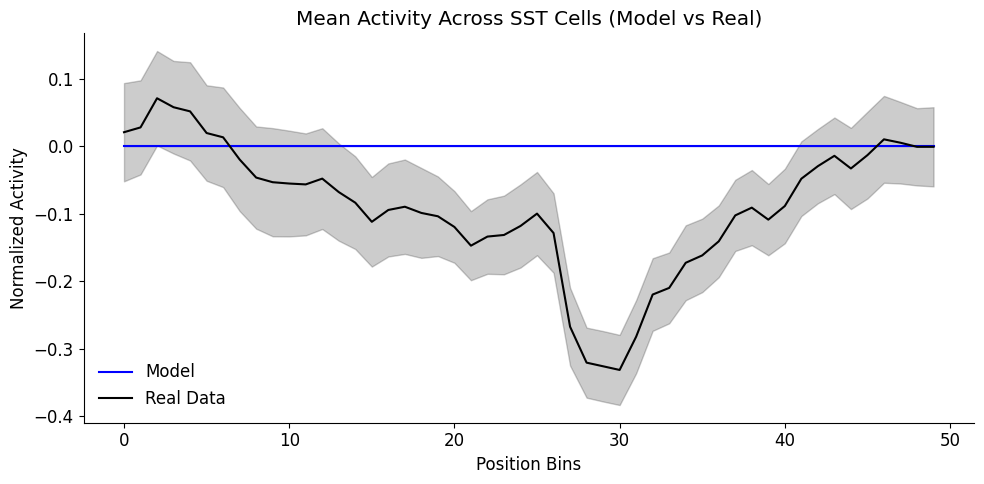

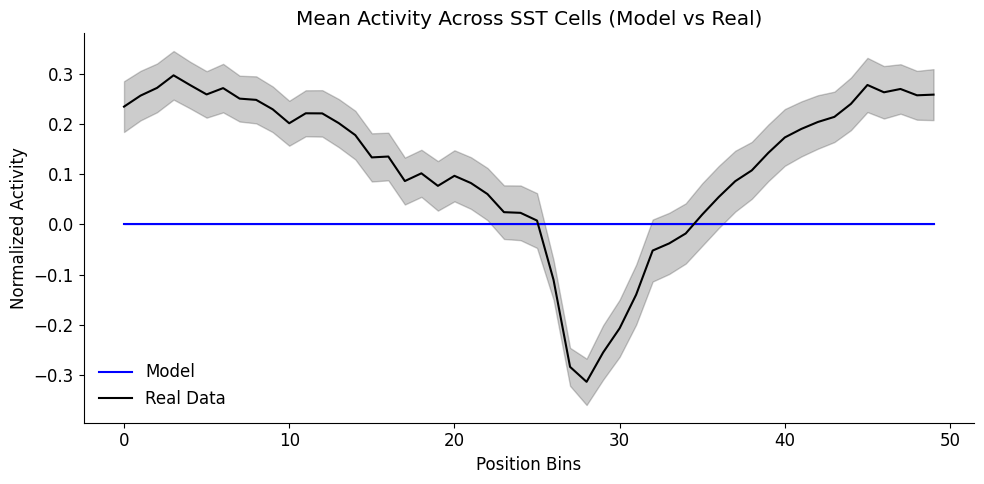

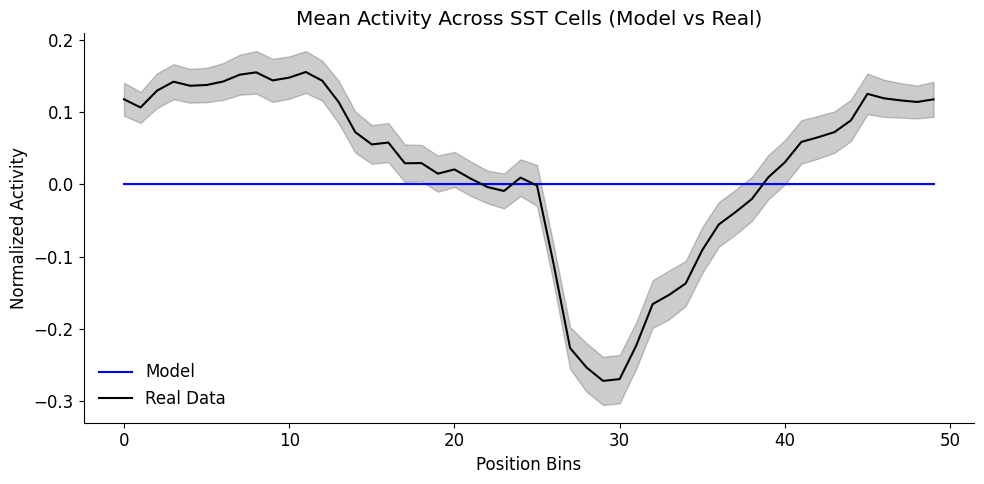

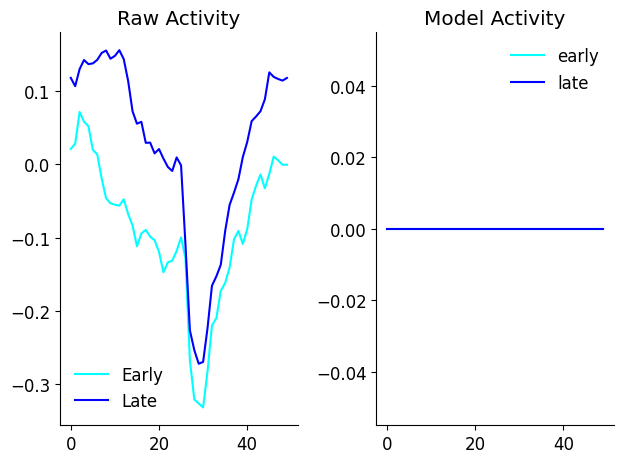

In [201]:
def compare_model_real_act(probability_activity_dict_SST, SST_data_dict_early_r, eml="early"):

    model_act_dict = {}
    real_activity_norm = {}

    for animal in SST_data_dict_early_r:
        model_act_dict_cell = {}
        real_cell_norm = {}

        for cell in SST_data_dict_early_r[animal]:

            real_data = SST_data_dict_early_r[animal][cell]

            real_cell_norm[cell] = real_data

            data_dict = probability_activity_dict_SST[animal][cell]

            prob_dict = {}
            activity_dict = {}

            activity_lists = {k: [] for k in ["before", "near", "after"]}

            # Safely collect field types that are present
            for field_type in ["before", "near", "after"]:
                if f"{field_type}_dict" in data_dict:
                    sub_dict = data_dict[f"{field_type}_dict"]

                    for key in sub_dict:
                        if eml == "early":
                            if "early" in key and "activity" not in key:
                                prob_dict[field_type] = np.mean(sub_dict[key])
                            elif "activity" in key:
                                activity_dict[field_type] = sub_dict[key]

                        elif eml == 'middle':
                            if "middle" in key and "activity" not in key:
                                prob_dict[field_type] = np.mean(sub_dict[key])
                            elif "activity" in key:
                                activity_dict[field_type] = sub_dict[key]
                        else:
                            if "late" in key and "activity" not in key:
                                prob_dict[field_type] = np.mean(sub_dict[key])
                            elif "activity" in key:
                                activity_dict[field_type] = sub_dict[key]

            activity_dict = {}
            for ftype in ["before", "near", "after"]:
                if len(activity_lists[ftype]) > 0:
                    stacked = np.stack(activity_lists[ftype], axis=0)  # (n, 50)
                    activity_dict[ftype] = np.mean(stacked, axis=0)
                else:
                    activity_dict[ftype] = np.zeros((50,), dtype=float)

            print(prob_dict.keys())

            available_fields = list(prob_dict.keys())
            if len(available_fields) == 0:
                continue

            field_probs = np.array([prob_dict[field] for field in available_fields])

            print(f"field_probs before {field_probs}")

            field_probs /= field_probs.sum()

            print(f"field_probs after {field_probs}")

            n_bins = 50
            n_trials = 20
            empty_trials = np.zeros((n_bins, n_trials))

            trial_types = np.random.choice(available_fields, size=n_trials, p=field_probs)

            for i, field in enumerate(trial_types):
                empty_trials[:, i] = activity_dict[field]

            # empty_trials_norm = (empty_trials - np.min(empty_trials)) / (np.max(empty_trials) - np.min(empty_trials))
            # empty_trials_norm =  v
            model_act_dict_cell[cell] = empty_trials

        model_act_dict[animal] = model_act_dict_cell
        real_activity_norm[animal] = real_cell_norm

    return model_act_dict, real_activity_norm


model_act_dict_e_SST, real_activity_norm_e_SST = compare_model_real_act(probability_activity_dict_SST, SST_data_dict_early_r, eml="early")
model_act_dict_m_SST, real_activity_norm_m_SST = compare_model_real_act(probability_activity_dict_SST, SST_data_dict_middle_r, eml="middle")
model_act_dict_l_SST, real_activity_norm_l_SST = compare_model_real_act(probability_activity_dict_SST, SST_data_dict_late_r, eml="late")


def plot_real_model(model_act_dict, real_activity_norm):
    real_list = []
    model_list = []

    for animal in model_act_dict:
        for cell in model_act_dict[animal]:
            real_list.append(np.mean(real_activity_norm[animal][cell], axis=1))
            model_list.append(np.mean(model_act_dict[animal][cell], axis=1))

    real_array = np.array(real_list)
    model_array = np.array(model_list)

    mean_real = np.mean(real_array, axis=0)
    sem_real = sem(real_array, axis=0)

    mean_model = np.mean(model_array, axis=0)
    sem_model = sem(model_array, axis=0)

    plt.figure(figsize=(10, 5))
    plt.plot(mean_model, label='Model', color='b')
    plt.fill_between(range(len(mean_model)), mean_model + sem_model, mean_model - sem_model, alpha=0.2, color='b')
    plt.plot(mean_real, label='Real Data', color='k')
    plt.fill_between(range(len(mean_real)), mean_real + sem_real, mean_real - sem_real, alpha=0.2, color='k')
    plt.xlabel("Position Bins")
    plt.ylabel("Normalized Activity")
    plt.title("Mean Activity Across SST Cells (Model vs Real)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return mean_real, sem_real, mean_model, sem_model


mean_real_e, sem_real_e, mean_model_e, sem_model_e = plot_real_model(model_act_dict_e_SST, real_activity_norm_e_SST)
mean_real_m, sem_real_m, mean_model_m, sem_model_m = plot_real_model(model_act_dict_m_SST, real_activity_norm_m_SST)
mean_real_l, sem_real_l, mean_model_l, sem_model_l = plot_real_model(model_act_dict_l_SST, real_activity_norm_l_SST)


fig, axs = plt.subplots(1,2)
axs[0].plot(mean_real_e, color='cyan', label='Early')
axs[0].plot(mean_real_l, color='blue', label='Late')
axs[0].legend()
axs[0].set_title("Raw Activity")

axs[1].plot(mean_model_e, color='cyan', label='early')
axs[1].plot(mean_model_l, color='blue', label='late')
axs[1].legend()
axs[1].set_title("Model Activity")

plt.tight_layout()
plt.show()



dict_keys(['near'])
field_probs before [0.51590909]
field_probs after [1.]
dict_keys(['near'])
field_probs before [0.5]
field_probs after [1.]
dict_keys(['before', 'near', 'after'])
field_probs before [0.1559322  0.53220339 0.31186441]
field_probs after [0.1559322  0.53220339 0.31186441]
dict_keys(['near', 'after'])
field_probs before [0.12045455 0.68863636]
field_probs after [0.1488764 0.8511236]
dict_keys(['before', 'near'])
field_probs before [0.22463768 0.35072464]
field_probs after [0.39042821 0.60957179]
dict_keys(['before', 'near', 'after'])
field_probs before [0.47681159 0.47246377 0.05072464]
field_probs after [0.47681159 0.47246377 0.05072464]
dict_keys(['near', 'after'])
field_probs before [0.075 0.25 ]
field_probs after [0.23076923 0.76923077]
dict_keys(['near', 'after'])
field_probs before [0.4  0.45]
field_probs after [0.47058824 0.52941176]
dict_keys(['before', 'near', 'after'])
field_probs before [0.23559322 0.3        0.46440678]
field_probs after [0.23559322 0.3      

/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_20267/177371696.py:54: RuntimeWarning: invalid value encountered in divide
  field_probs /= field_probs.sum()


ValueError: probabilities contain NaN

dict_keys(['before', 'after'])
[0.37857143 0.35       0.27142857]
dict_keys(['before', 'near', 'after'])
[0.56666667 0.4        0.03333333]
dict_keys(['near', 'after'])
[0.37647059 0.44705882 0.17647059]
dict_keys(['before', 'near', 'after'])
[0.13333333 0.24444444 0.62222222]
dict_keys(['before', 'near', 'after'])
[0.23820225 0.53932584 0.22247191]
dict_keys(['before', 'after'])
[0.02352941 0.48823529 0.48823529]
dict_keys(['before', 'near', 'after'])
[0.5        0.14444444 0.35555556]
dict_keys(['before', 'near', 'after'])
[0.1296875 0.753125  0.1171875]
dict_keys(['before', 'near', 'after'])
[0.24411765 0.07352941 0.68235294]
dict_keys(['before', 'near', 'after'])
[0.15526316 0.11491228 0.72982456]
dict_keys(['before', 'after'])
[0.57894737 0.26491228 0.15614035]
dict_keys(['before', 'near', 'after'])
[0.17916667 0.4125     0.40833333]
dict_keys(['before', 'near', 'after'])
[0.19491525 0.58813559 0.21694915]
dict_keys(['before', 'near', 'after'])
[0.65833333 0.04583333 0.29583333]
d

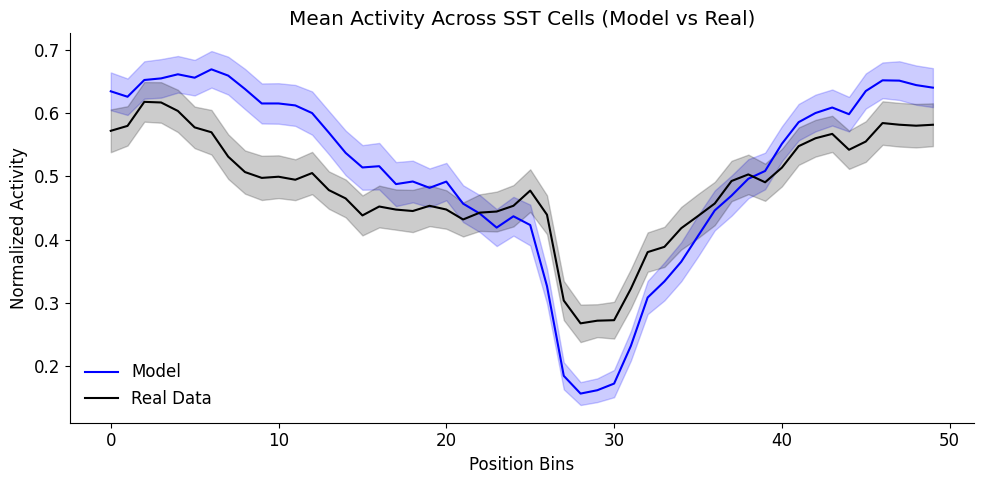

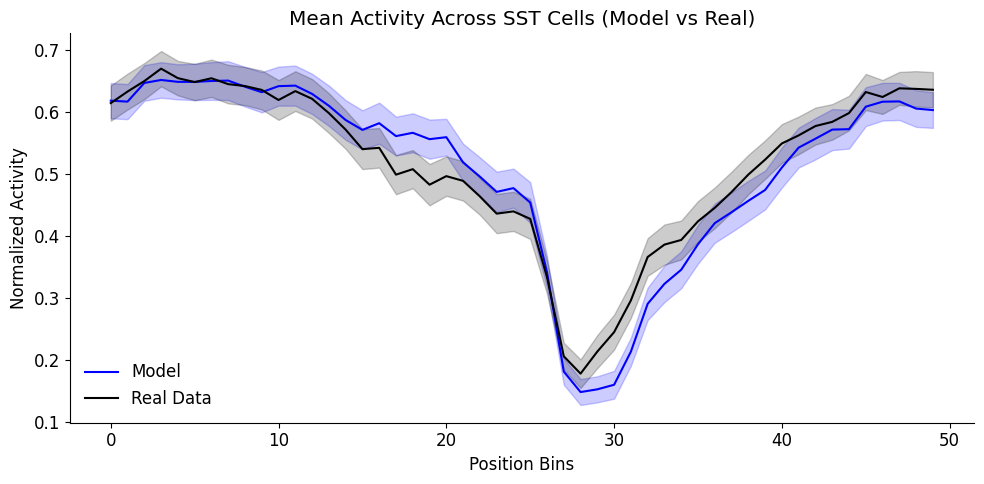

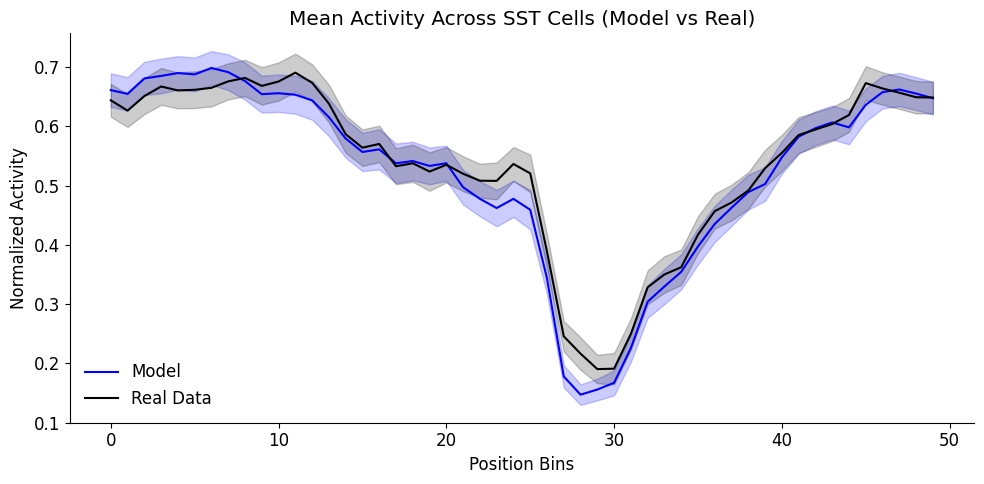

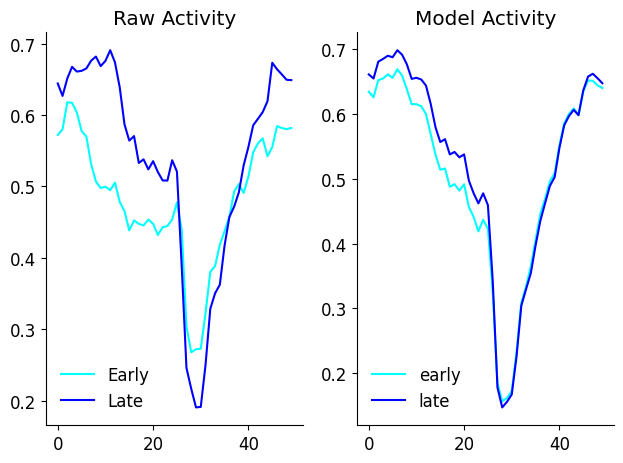

In [223]:
def compare_model_real_act(probability_activity_dict_SST, SST_data_dict_early_r, inits=0.2, vol=0.01, eml="early"):

    model_act_dict = {}
    real_activity_norm = {}

    for animal in SST_data_dict_early_r:
        model_act_dict_cell = {}
        real_cell_norm = {}

        for cell in SST_data_dict_early_r[animal]:

            real_data = SST_data_dict_early_r[animal][cell]

            real_cell_norm[cell] = real_data

            data_dict = probability_activity_dict_SST[animal][cell]

            prob_dict = {}
            activity_dict = {}

            # Safely collect field types that are present
            for field_type in ["before", "near", "after"]:
                if f"{field_type}_dict" in data_dict:
                    sub_dict = data_dict[f"{field_type}_dict"]

                    for key in sub_dict:
                        if eml == "early":
                            if "early" in key and "activity" not in key:
                                prob_dict[field_type] = np.mean(sub_dict[key])
                            elif "activity" in key:
                                activity_dict[field_type] = sub_dict[key]

                        elif eml == 'middle':
                            if "middle" in key and "activity" not in key:
                                prob_dict[field_type] = np.mean(sub_dict[key])
                            elif "activity" in key:
                                activity_dict[field_type] = sub_dict[key]
                        else:
                            if "late" in key and "activity" not in key:
                                prob_dict[field_type] = np.mean(sub_dict[key])
                            elif "activity" in key:
                                activity_dict[field_type] = sub_dict[key]

            print(prob_dict.keys())

            available_fields = list(prob_dict.keys())
            field_probs = np.array([prob_dict[field] for field in available_fields])
            sum_probs = np.sum(field_probs)

            if sum_probs < 1.0:
                # Add a synthetic noise field to make probs sum to 1
                noise_field_name = "noise"
                noise_prob = 1.0 - sum_probs
                available_fields.append(noise_field_name)
                field_probs = np.append(field_probs, noise_prob)
                
                
                # Add random noise activity
                n_bins = 50
                activity_dict[noise_field_name] = random_timeseries(initial_value=inits, volatility=vol, count=49)
            # elif sum_probs > 1.0:
            #     # Optional safety: normalize if the sum overshoots slightly due to float rounding
            #     field_probs = field_probs / sum_probs

            print(field_probs)

            n_bins = 50
            n_trials = 20
            empty_trials = np.zeros((n_bins, n_trials))

            trial_types = np.random.choice(available_fields, size=n_trials, p=field_probs)

            for i, field in enumerate(trial_types):
                empty_trials[:, i] = activity_dict[field]

            # empty_trials_norm = (empty_trials - np.min(empty_trials)) / (np.max(empty_trials) - np.min(empty_trials))
            # empty_trials_norm =  v
            model_act_dict_cell[cell] = empty_trials

        model_act_dict[animal] = model_act_dict_cell
        real_activity_norm[animal] = real_cell_norm

    return model_act_dict, real_activity_norm


model_act_dict_e_SST, real_activity_norm_e_SST = compare_model_real_act(probability_activity_dict_SST, SST_data_dict_early_r, eml="early")
model_act_dict_m_SST, real_activity_norm_m_SST = compare_model_real_act(probability_activity_dict_SST, SST_data_dict_middle_r, eml="middle")
model_act_dict_l_SST, real_activity_norm_l_SST = compare_model_real_act(probability_activity_dict_SST, SST_data_dict_late_r, eml="late")


def plot_real_model(model_act_dict, real_activity_norm, min_max=True):
    real_list = []
    model_list = []

    for animal in model_act_dict:
        for cell in model_act_dict[animal]:
            act = real_activity_norm[animal][cell]
            mod = model_act_dict[animal][cell]

            

            mean_act = np.mean(act, axis=1)
            mean_mod = np.mean(mod, axis=1)

            if min_max:
                mean_act = (mean_act - np.min(mean_act)) / (np.max(mean_act) - np.min(mean_act))
                mean_mod = (mean_mod - np.min(mean_mod)) / (np.max(mean_mod) - np.min(mean_mod))

            real_list.append(mean_act)
            model_list.append(mean_mod)

    real_array = np.array(real_list)
    model_array = np.array(model_list)

    mean_real = np.mean(real_array, axis=0)
    sem_real = sem(real_array, axis=0)

    mean_model = np.mean(model_array, axis=0)
    sem_model = sem(model_array, axis=0)

    plt.figure(figsize=(10, 5))
    plt.plot(mean_model, label='Model', color='b')
    plt.fill_between(range(len(mean_model)), mean_model + sem_model, mean_model - sem_model, alpha=0.2, color='b')
    plt.plot(mean_real, label='Real Data', color='k')
    plt.fill_between(range(len(mean_real)), mean_real + sem_real, mean_real - sem_real, alpha=0.2, color='k')
    plt.xlabel("Position Bins")
    plt.ylabel("Normalized Activity")
    plt.title("Mean Activity Across SST Cells (Model vs Real)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return mean_real, sem_real, mean_model, sem_model


mean_real_e, sem_real_e, mean_model_e, sem_model_e = plot_real_model(model_act_dict_e_SST, real_activity_norm_e_SST, min_max=True)
mean_real_m, sem_real_m, mean_model_m, sem_model_m = plot_real_model(model_act_dict_m_SST, real_activity_norm_m_SST, min_max=True)
mean_real_l, sem_real_l, mean_model_l, sem_model_l = plot_real_model(model_act_dict_l_SST, real_activity_norm_l_SST, min_max=True)


fig, axs = plt.subplots(1,2)
axs[0].plot(mean_real_e, color='cyan', label='Early')
axs[0].plot(mean_real_l, color='blue', label='Late')
axs[0].legend()
axs[0].set_title("Raw Activity")

axs[1].plot(mean_model_e, color='cyan', label='early')
axs[1].plot(mean_model_l, color='blue', label='late')
axs[1].legend()
axs[1].set_title("Model Activity")

plt.tight_layout()
plt.show()



In [203]:
import random

dict_keys(['near'])
dict_keys(['near'])
dict_keys(['before', 'near', 'after'])
dict_keys(['near', 'after'])
dict_keys(['before', 'near'])
dict_keys(['before', 'near', 'after'])
dict_keys(['near', 'after'])
dict_keys(['near', 'after'])
dict_keys(['before', 'near', 'after'])
dict_keys(['before', 'near'])
dict_keys(['near'])
dict_keys(['before', 'near'])
dict_keys(['near', 'after'])
dict_keys(['before', 'near'])
dict_keys(['before', 'near'])
dict_keys(['near'])
dict_keys(['before', 'near'])
dict_keys(['near', 'after'])
dict_keys(['near'])
dict_keys(['before', 'near', 'after'])
dict_keys(['before', 'near', 'after'])
dict_keys(['before', 'near', 'after'])
dict_keys(['before', 'after'])
dict_keys(['near'])
dict_keys(['near', 'after'])
dict_keys(['near', 'after'])
dict_keys(['near', 'after'])
dict_keys(['before', 'near', 'after'])
dict_keys(['before', 'near'])
dict_keys(['before', 'near', 'after'])
dict_keys(['before', 'after'])
dict_keys(['before', 'near', 'after'])
dict_keys(['before', 'nea

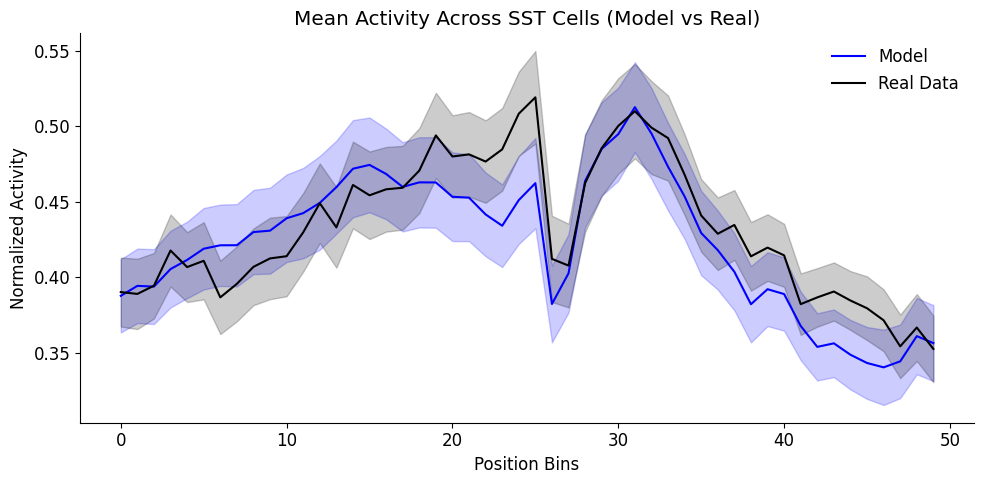

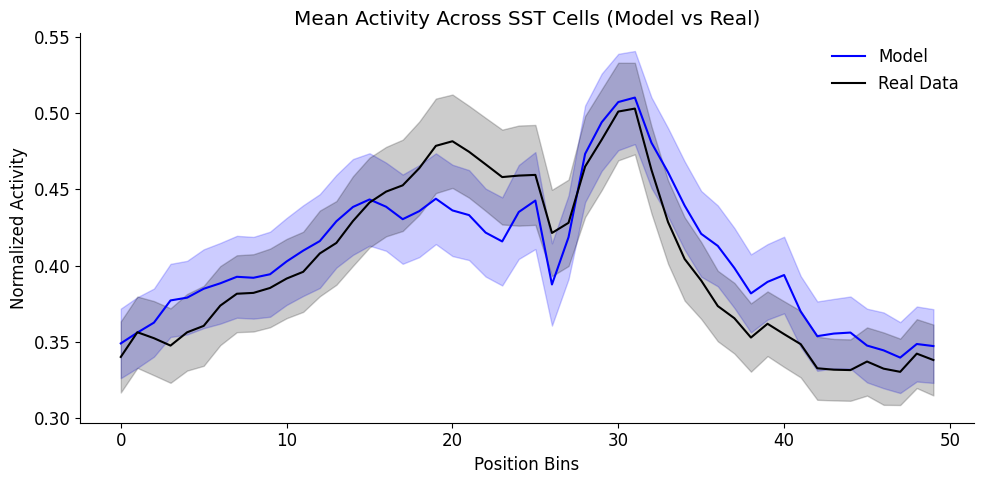

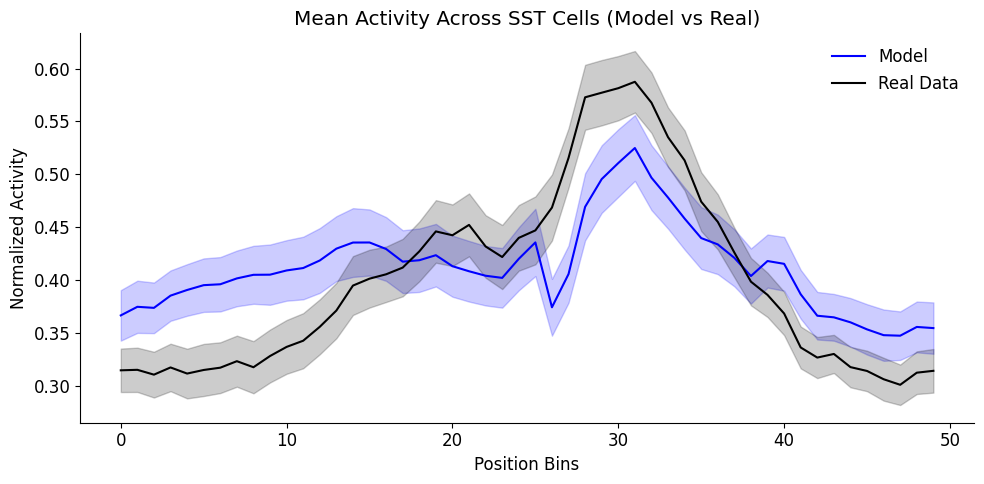

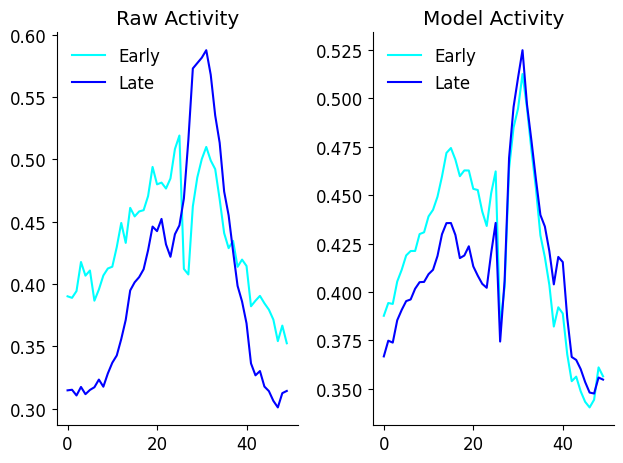

In [222]:
probability_activity_dict_NDNF = get_labels_activities_eml(fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF, sort_by_peak=True)

model_act_dict_e_NDNF, real_activity_norm_e_NDNF = compare_model_real_act(probability_activity_dict_NDNF, NDNF_data_dict_early_r, eml="early")
model_act_dict_m_NDNF, real_activity_norm_m_NDNF = compare_model_real_act(probability_activity_dict_NDNF, NDNF_data_dict_middle_r, eml="middle")
model_act_dict_l_NDNF, real_activity_norm_l_NDNF = compare_model_real_act(probability_activity_dict_NDNF, NDNF_data_dict_late_r, eml="late")


mean_real_e, sem_real_e, mean_model_e, sem_model_e = plot_real_model(model_act_dict_e_NDNF, real_activity_norm_e_NDNF, min_max=True)
mean_real_m, sem_real_m, mean_model_m, sem_model_m = plot_real_model(model_act_dict_m_NDNF, real_activity_norm_m_NDNF, min_max=True)
mean_real_l, sem_real_l, mean_model_l, sem_model_l = plot_real_model(model_act_dict_l_NDNF, real_activity_norm_l_NDNF, min_max=True)


fig, axs = plt.subplots(1,2)
axs[0].plot(mean_real_e, color='cyan', label='Early')
axs[0].plot(mean_real_l, color='blue', label='Late')
# axs[0].plot(mean_real_m, color='k', label='Middle')
axs[0].legend()
axs[0].set_title("Raw Activity")

axs[1].plot(mean_model_e, color='cyan', label='Early')
axs[1].plot(mean_model_l, color='blue', label='Late')
# axs[1].plot(mean_model_m, color='k', label='Middle')
axs[1].legend()
axs[1].set_title("Model Activity")

plt.tight_layout()
plt.show()

In [224]:
probability_activity_dict_EC = get_labels_activities_eml(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, cp_dict_EC, sort_by_peak=True)

model_act_dict_e_EC, real_activity_norm_e_EC = compare_model_real_act(probability_activity_dict_EC, EC_data_dict_early_r, eml="early")
model_act_dict_m_EC, real_activity_norm_m_EC = compare_model_real_act(probability_activity_dict_EC, EC_data_dict_middle_r, eml="middle")
model_act_dict_l_EC, real_activity_norm_l_EC = compare_model_real_act(probability_activity_dict_EC, EC_data_dict_late_r, eml="late")


mean_real_e, sem_real_e, mean_model_e, sem_model_e = plot_real_model(model_act_dict_e_EC, real_activity_norm_e_EC, min_max=True)
mean_real_m, sem_real_m, mean_model_m, sem_model_m = plot_real_model(model_act_dict_m_EC, real_activity_norm_m_EC, min_max=True)
mean_real_l, sem_real_l, mean_model_l, sem_model_l = plot_real_model(model_act_dict_l_EC, real_activity_norm_l_EC, min_max=True)


fig, axs = plt.subplots(1,2)
axs[0].plot(mean_real_e, color='cyan', label='Early')
axs[0].plot(mean_real_l, color='blue', label='Late')
# axs[0].plot(mean_real_m, color='k', label='Middle')
axs[0].legend()
axs[0].set_title("Raw Activity")

axs[1].plot(mean_model_e, color='cyan', label='Early')
axs[1].plot(mean_model_l, color='blue', label='Late')
# axs[1].plot(mean_model_m, color='k', label='Middle')
axs[1].legend()
axs[1].set_title("Model Activity")

plt.tight_layout()
plt.show()

dict_keys(['before', 'near', 'after'])
[1.02564103e-01 7.94871795e-01 1.02564103e-01 1.11022302e-16]
dict_keys(['before', 'near', 'after'])
[0.11111111 0.11111111 0.77777778]
dict_keys(['before', 'near', 'after'])
[0.00000000e+00 9.42105263e-01 5.78947368e-02 1.11022302e-16]
dict_keys(['before', 'near', 'after'])
[0.09487179 0.06923077 0.83589744]
dict_keys(['before', 'near', 'after'])
[8.63157895e-01 3.15789474e-02 1.05263158e-01 1.11022302e-16]
dict_keys(['before', 'after'])
[0.20294118 0.59117647 0.20588235]
dict_keys(['before', 'near'])
[0.11428571 0.04285714 0.84285714]
dict_keys(['before', 'near'])
[0.11428571 0.04285714 0.84285714]
dict_keys(['before', 'near', 'after'])
[0.1122449  0.74897959 0.13877551]
dict_keys(['before', 'near', 'after'])
[0.1122449  0.74897959 0.13877551]
dict_keys(['before', 'near', 'after'])
[0.075      0.84166667 0.08333333]
dict_keys(['before', 'near', 'after'])
[0.075      0.84166667 0.08333333]
dict_keys(['before', 'near', 'after'])
[0.075      0.8416

/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: probabilities contain NaN

In [225]:
pwd

'/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date'

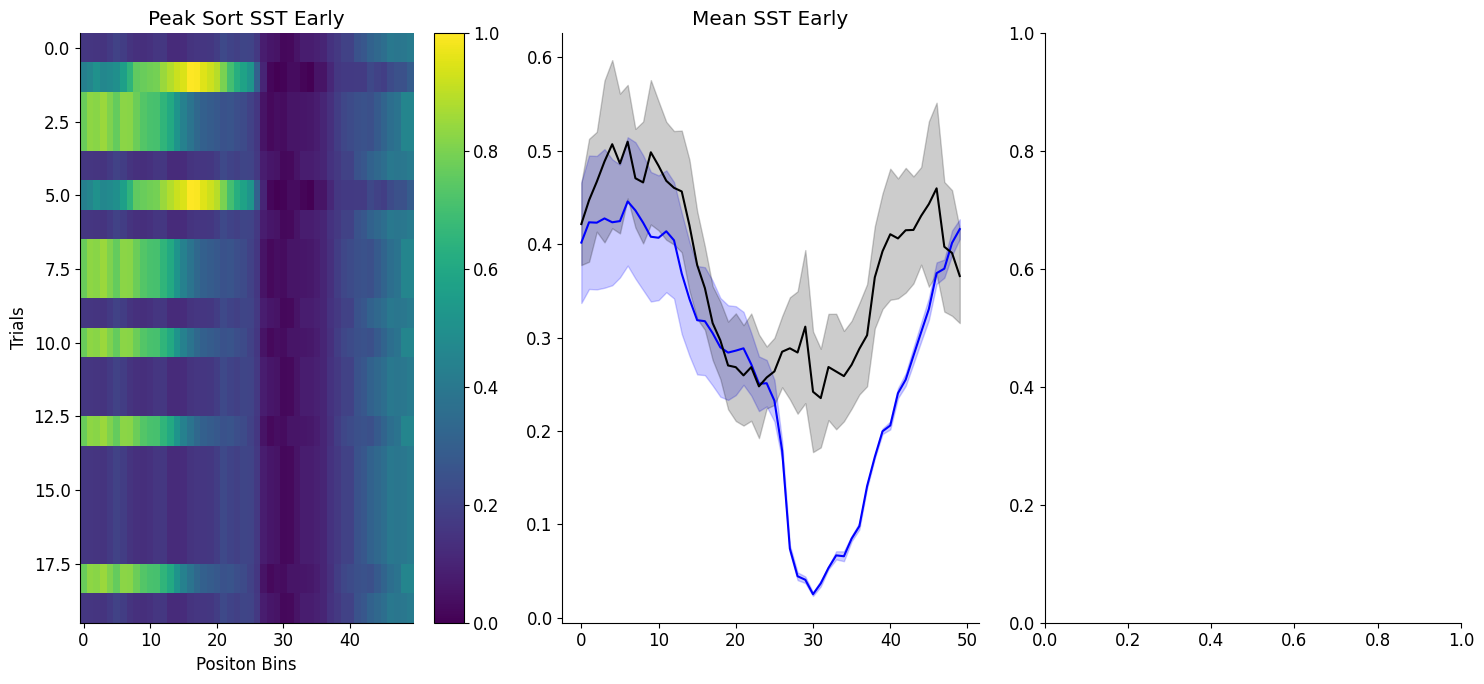

In [ ]:
####### plotting a single cell 


animal=1
cell=1

empty_trials = np.zeros((50,20))

empty_trialsreal_data = SST_data_dict_early_r[animal][cell]
real_data_norm = (real_data - np.min(real_data)) / (np.max(real_data) - np.min(real_data))
mean_data_ta = np.mean(real_data_norm, axis=1)
sem_data_ta = sem(real_data_norm, axis=1)

data_dict = probability_activity_dict_SST[animal][cell]

for i in data_dict:
    if "after" in i:
        for j in probability_after_field:
            if "activity" in j:
                after_field_activity_array = probability_activity_dict_SST[animal][cell][i]["activity_1"]
            else:
                probability_after_field = np.mean(probability_activity_dict_SST[animal][cell]["after_dict"]["after_early_1"])



# probability_after_field = np.mean(probability_activity_dict_SST[animal][cell]["after_dict"]["after_early_1"])
# after_field_activity_array = probability_activity_dict_SST[animal][cell]["after_dict"]["activity_1"]
# probability_near_field = np.mean(probability_activity_dict_SST[animal][cell]["near_dict"]["near_early_2"])
# near_field_activity_array = probability_activity_dict_SST[animal][cell]["near_dict"]["activity_2"]
# probability_before_field = np.mean(probability_activity_dict_SST[animal][cell]["before_dict"]["before_early_0"])
# before_field_activity_array = probability_activity_dict_SST[animal][cell]["before_dict"]["activity_0"]

probs = np.array([probability_before_field, probability_near_field, probability_after_field])
probs /= probs.sum()

# Step 4: Sample trial types
trial_types = np.random.choice(['before', 'near', 'after'], size=empty_trials.shape[1], p=probs)


for i, field in enumerate(trial_types):
    if field == "before":
        empty_trials[:,i] = before_field_activity_array
    if field == "near":
        empty_trials[:,i] = near_field_activity_array
    if field == "after":
        empty_trials[:,i] = after_field_activity_array

empty_trials_norm = (empty_trials - np.min(empty_trials)) / (np.max(empty_trials) - np.min(empty_trials))

fig, axs = plt.subplots(1,3, figsize=(15,7))
im = axs[0].imshow(empty_trials_norm.T, aspect='auto')
axs[0].set_title("Peak Sort SST Early")
axs[0].set_ylabel("Trials")
axs[0].set_xlabel("Positon Bins")
fig.colorbar(im, ax=axs[0])

axs[1].set_title("Mean SST Early")
mean_act = np.mean(empty_trials_norm, axis=1)
sem_act = sem(empty_trials_norm, axis=1)
axs[1].plot(mean_act, label='Model', color='b')
axs[1].fill_between(range(len(mean_act)), mean_act+sem_act, mean_act-sem_act, alpha=0.2, color='b')

axs[1].plot(mean_data_ta, label='Raw Activity', color='k')
axs[1].fill_between(range(len(mean_data_ta)), mean_data_ta+sem_data_ta, mean_data_ta-sem_data_ta, alpha=0.2, color='k')

plt.tight_layout()
plt.show()